# 1.Business understanding


## 1.1 Contexto del negocio

En Rappi, la **disponibilidad de tiendas** es un indicador operativo crítico.
Cuando una tienda deja de ser visible para los usuarios en la plataforma, el impacto
es inmediato: los usuarios no pueden hacer pedidos, lo que se traduce en pérdida de
ingresos y deterioro de la experiencia.

Rappi monitorea de forma continua cuántas tiendas están disponibles en la plataforma
para detectar comportamientos anómalos y reaccionar a tiempo ante caídas de disponibilidad.

---

## 1.2 Objetivo del negocio

> Entender cómo se comporta la disponibilidad agregada de tiendas a lo largo del tiempo,
> identificar en qué franjas horarias ocurren caídas o inestabilidades, y detectar
> patrones que permitan anticipar o diagnosticar problemas operacionales en la plataforma.

---

## 1.3 Preguntas de negocio

| # | Pregunta |
|---|---|
| 1 | ¿En qué momentos del día la disponibilidad de tiendas es más baja? |
| 2 | ¿Existen caídas abruptas que puedan indicar incidentes en la plataforma? |
| 3 | ¿Cuánto tiempo tarda la plataforma en recuperar su nivel normal tras una caída? |
| 4 | ¿Hay franjas horarias con mayor inestabilidad en la disponibilidad? |
| 5 | ¿La disponibilidad sigue un patrón predecible a lo largo del día? |

---

## 1.4 Criterios de éxito

Esta fase tiene un único objetivo: transformar los archivos CSV de monitoreo en una
**base de datos consolidada, limpia y estructurada** que pueda ser consumida por las
fases posteriores del proyecto (dashboard web y agente semántico).

El resultado de esta fase se considerará exitoso si:

1. Todos los archivos CSV de distintas franjas horarias quedan **integrados en una sola
   fuente de datos** sin duplicados ni inconsistencias.
2. Los datos están **limpios y normalizados**, con timestamps correctamente parseados
   y valores atípicos o faltantes tratados de forma explícita y documentada.
3. Se generan los **KPIs e indicadores clave** derivados de los datos crudos
   (promedios por franja, detección de caídas, métricas de recuperación, etc.)
   listos para ser consultados en las fases siguientes.
4. La base de datos resultante está en un **formato estructurado y accesible**
   que permite tanto alimentar visualizaciones interactivas (Bloque 2)
   como ser consultada por lenguaje natural a través del agente de IA (Bloque 3).

# 2. Data undestanding

In [140]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)

## 2.1 Carga de datos
Cargaremos el archivo histórico de disponibilidad. El archivo CSV proporcionado tiene una estructura "ancha" (wide format) donde cada columna representa un timestamp de muestreo y la fila contiene los valores, esto suele ser un export directo de herramientas de monitoreo.

In [141]:
file_path = r'../../../DATOS/DATOS_CRUDOS/AVAILABILITY-data.csv'
df_raw = pd.read_csv(file_path)

print(f'Dimensiones del dataset original: {df_raw.shape}')
# Mostramos la cabecera y 10 primeras columnas de tiempo
df_raw.iloc[:, :10].head()

Dimensiones del dataset original: (1, 297)


,Plot name,metric (sf_metric),Value Prefix,Value Suffix,Sun Feb 01 2026 06:11:20 GMT-0500 (hora estándar de Colombia),Sun Feb 01 2026 06:11:30 GMT-0500 (hora estándar de Colombia),Sun Feb 01 2026 06:11:40 GMT-0500 (hora estándar de Colombia),Sun Feb 01 2026 06:11:50 GMT-0500 (hora estándar de Colombia),Sun Feb 01 2026 06:12:00 GMT-0500 (hora estándar de Colombia),Sun Feb 01 2026 06:12:10 GMT-0500 (hora estándar de Colombia)
0,NOW,synthetic_monitoring_visible_stores,NaN,NaN,37,195,451,489,911,1047


## 2.2 Transformación Inicial (Melt)
Para realizar un análisis temporal y estadístico adecuado, requerimos que los datos tengan una estructura larga (long format) donde cada registro sea la combinación `(timestamp, visible_stores)`.

In [142]:
id_cols = ['Plot name', 'metric (sf_metric)', 'Value Prefix', 'Value Suffix']

# Hacemos un melt para bajar los timestamps a filas
df_long = pd.melt(df_raw, id_vars=id_cols, var_name='timestamp_raw', value_name='visible_stores')

# Limpiamos el texto del timestamp usando una expresión regular para remover "(hora estándar de Colombia)" y dejar el timezone "+-0500"
df_long['timestamp_raw'] = df_long['timestamp_raw'].str.extract(r'(.* GMT[+-]\d{4})')[0]

# Parseamos a Datetime indicando el format string exacto
df_long['timestamp'] = pd.to_datetime(df_long['timestamp_raw'], format='%a %b %d %Y %H:%M:%S GMT%z')

# Nos quedamos con las columnas útiles
df_clean = df_long[['timestamp', 'visible_stores']].copy()

# Ordenamos obligatoriamente por fecha para el EDA
df_clean.sort_values('timestamp', inplace=True)
df_clean.reset_index(drop=True, inplace=True)

df_clean.head()

,timestamp,visible_stores
0,2026-02-01 06:11:20-05:00,37
1,2026-02-01 06:11:30-05:00,195
2,2026-02-01 06:11:40-05:00,451
3,2026-02-01 06:11:50-05:00,489
4,2026-02-01 06:12:00-05:00,911


## 2.3 Exploración Básica (EDA)
Una vez transformada la data, validaremos nulos, la completitud de la medición y estadísticas básicas.

In [143]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 293 entries, 0 to 292
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype                    
---  ------          --------------  -----                    
 0   timestamp       293 non-null    datetime64[us, UTC-05:00]
 1   visible_stores  293 non-null    int64                    
dtypes: datetime64[us, UTC-05:00](1), int64(1)
memory usage: 4.7 KB


In [144]:
# Revisar las analíticas descriptivas
df_clean.describe()

,visible_stores
count,293.000000
mean,14323.344710
std,5419.677345
min,37.000000
25%,11087.000000
50%,15654.000000
75%,18449.000000
max,20762.000000


In [145]:
# Verificamos si hay nulos creados durante el pivoting o por falta de datos
print("Valores nulos en el dataset:")
print(df_clean.isnull().sum())

Valores nulos en el dataset:
timestamp         0
visible_stores    0
dtype: int64


# 3. Data Preparation
## 3.1 Consolidación de todos los archivos CSV históricos
Dado que tenemos una gran cantidad de archivos CSV segmentados, la siguiente función se encarga de iterar sobre el directorio entero, aplicar el pipeling de transformación (Wide-to-Long) en cada unidad, y luego unir el universo completo en un solo DataFrame de pandas.

In [146]:
import glob
import os

raw_data_dir = r'../../../DATOS/DATOS_CRUDOS/'
# Hacemos la busqueda de todos los archivos que coincidan
all_files = glob.glob(os.path.join(raw_data_dir, "AVAILABILITY-data*.csv"))

print(f"Encontrados {len(all_files)} archivos para consolidar.")

dfs_list = []
id_cols = ['Plot name', 'metric (sf_metric)', 'Value Prefix', 'Value Suffix']

for file in all_files:
    try:
        # 1. Lectura del CSV temporal
        df_temp = pd.read_csv(file)
        
        # 2. Hacer el pivot (Wide a Long)
        df_melted = pd.melt(df_temp, id_vars=id_cols, var_name='timestamp_raw', value_name='visible_stores')
        
        # 3. Extracción de zona horaria y casting a Datetime
        df_melted['timestamp_raw'] = df_melted['timestamp_raw'].str.extract(r'(.* GMT[+-]\d{4})')[0]
        # Coerce es útil por si algún registro de un CSV corrupto no puede convertirse
        df_melted['timestamp'] = pd.to_datetime(df_melted['timestamp_raw'], format='%a %b %d %Y %H:%M:%S GMT%z', errors='coerce')
        
        # 4. Quedarnos únicamente con timestamp y métrica, y descartar NAs si los hay
        df_melted = df_melted[['timestamp', 'visible_stores']].dropna()
        
        # 5. Volcar a la matriz principal
        dfs_list.append(df_melted)
        
    except Exception as e:
        print(f"Error procesando el archivo {os.path.basename(file)}: {e}")

# 6. Concatenar los 200+ archivos
print("Concatenando todos los registros... esto puede tomar un poco.")
df_consolidado = pd.concat(dfs_list, ignore_index=True)

# 7. Eliminar si hay tiempos duplicados entre archivos (snapshots traslapados)
df_consolidado.drop_duplicates(subset=['timestamp'], inplace=True)

# 8. Ordenar cronológicamente para que la serie de tiempo tenga coherencia y reset del index
df_consolidado.sort_values('timestamp', inplace=True)
df_consolidado.reset_index(drop=True, inplace=True)

print(f"Dimensión final del Dataset Consolidado: {df_consolidado.shape}")
df_consolidado.head()

Encontrados 201 archivos para consolidar.
Concatenando todos los registros... esto puede tomar un poco.
Dimensión final del Dataset Consolidado: (67141, 2)


,timestamp,visible_stores
0,2026-02-01 06:11:20-05:00,37
1,2026-02-01 06:11:30-05:00,195
2,2026-02-01 06:11:40-05:00,451
3,2026-02-01 06:11:50-05:00,489
4,2026-02-01 06:12:00-05:00,911


## 3.2 Limpieza y tratamiento de ruido
Garantizamos tipologías correctas para las columnas.

In [147]:
# Convertir a numérico estricto y luego forzar Int64 (ya que son conteos de tiendas)
df_consolidado['visible_stores'] = pd.to_numeric(df_consolidado['visible_stores'], errors='coerce')
df_consolidado = df_consolidado.dropna()

# Cast int
df_consolidado['visible_stores'] = df_consolidado['visible_stores'].astype(int)

df_consolidado.info()

<class 'pandas.DataFrame'>
RangeIndex: 67141 entries, 0 to 67140
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype                    
---  ------          --------------  -----                    
 0   timestamp       67141 non-null  datetime64[us, UTC-05:00]
 1   visible_stores  67141 non-null  int64                    
dtypes: datetime64[us, UTC-05:00](1), int64(1)
memory usage: 1.0 MB


## 3.3 Guardar el Output Final Procesado
Enviamos esta base de datos consolidada a `DATOS_PROCESADOS`. 
Este archivo consolida **todo el esfuerzo de preparación de la data** y es el Dataset Entregable de la Fase 1 que luego ingestaremos en la Web (Fase 2) y usaremos de contexto para la IA (Fase 3).

In [148]:
processed_dir = r'../../../DATOS/DATOS_PROCESADOS/'
os.makedirs(processed_dir, exist_ok=True)

output_path = os.path.join(processed_dir, 'AVAILABILITY-procesado.csv')
df_consolidado.to_csv(output_path, index=False)

print(f"¡Dataset estructurado, procesado y consolidado guardado exitosamente!\nRuta: {output_path}")

¡Dataset estructurado, procesado y consolidado guardado exitosamente!
Ruta: ../../../DATOS/DATOS_PROCESADOS/AVAILABILITY-procesado.csv


## 3.4 Feature Engineering (Datasets Listos para Modeling)
Las ideas presentadas a nivel de negocio para el modelo (K-Means por días, series de tiempo ARMA/Prophet) son muy acertadas. Para lograrlo directamente en la fase de **Modeling**, dejaremos ya pre-construidos y procesados tres (3) configuraciones del dataset:

1. **Dataset con Features Temporales Geocéntricos**: Extracción de franjas horarias y días clave.
2. **Dataset Resampleado (Serie temporal)**: Consolidación por horas y suavizado para algoritmos Autoregresivos.
3. **Dataset de Perfiles Diarios (Clustering)**: Forma pivotada de horas horizontales por día (24 columnas) listo para ser ingerido por K-Means.

In [149]:
import warnings
warnings.filterwarnings('ignore')

# 1. Feature Engineering: Variables temporales
df_features = df_consolidado.copy()

# Extracción de características
df_features['hour'] = df_features['timestamp'].dt.hour
df_features['day_of_week'] = df_features['timestamp'].dt.dayofweek
df_features['is_weekend'] = df_features['day_of_week'].isin([5, 6]).astype(int)
df_features['date'] = df_features['timestamp'].dt.date

# Crear Franjas Horarias
bins = [0, 6, 12, 18, 24]
labels = ['Madrugada', 'Mañana', 'Tarde', 'Noche']
# Usamos right=False para que 06:00 pertenezca a 'Mañana' y no 'Madrugada'
df_features['time_band'] = pd.cut(df_features['hour'], bins=bins, labels=labels, right=False)

df_features.head()

,timestamp,visible_stores,hour,day_of_week,is_weekend,date,time_band
0,2026-02-01 06:11:20-05:00,37,6,6,1,2026-02-01,Mañana
1,2026-02-01 06:11:30-05:00,195,6,6,1,2026-02-01,Mañana
2,2026-02-01 06:11:40-05:00,451,6,6,1,2026-02-01,Mañana
3,2026-02-01 06:11:50-05:00,489,6,6,1,2026-02-01,Mañana
4,2026-02-01 06:12:00-05:00,911,6,6,1,2026-02-01,Mañana


### Generación de Datasets Estructurales para Modelos

In [150]:
# A) Dataset de Serie de Tiempo (Remuestreo)
# Para modelado autorregresivo nos sirve que las observaciones sean equidistantes en el tiempo.
# Agruparemos (resample) por 1 HORA y promediaremos la cantidad para suavizar el ruido de la medición corta.

df_hourly = df_features.set_index('timestamp').resample('1h')['visible_stores'].mean().reset_index()

# Si algún tramo en la noche no tuvo data y quedo NaN, lo rellenamos interpolando linealmente.
# Usamos bfill() o ffill() o interpolate() para mayor precisión.
df_hourly['visible_stores'] = df_hourly['visible_stores'].interpolate(method='linear')
df_hourly.dropna(inplace=True)
df_hourly['visible_stores'] = df_hourly['visible_stores'].round(0).astype("Int64")

print(f"Dataset Autorregresivo (Horario): {df_hourly.shape}")
df_hourly.head()

Dataset Autorregresivo (Horario): (250, 2)


,timestamp,visible_stores
0,2026-02-01 06:00:00-05:00,14308
1,2026-02-01 07:00:00-05:00,33525
2,2026-02-01 08:00:00-05:00,327085
3,2026-02-01 09:00:00-05:00,1036630
4,2026-02-01 10:00:00-05:00,1836326


In [151]:
# B) Dataset de Perfiles Diarios para Clustering (K-Means)
# Transformamos a un data-frame donde las columnas son '0'...'23' (las horas de un dia). 
# Cada Fila es una fecha y muestra el comportamiento de tiendas en todo el transcurso del día.

df_clustering = df_features.pivot_table(
    index='date', 
    columns='hour', 
    values='visible_stores', 
    aggfunc='mean'
)

# Rellenar posibles gaps de horas faltantes interpolando vecinos del mismo día, o usando el día anterior.
df_clustering = df_clustering.ffill(axis=1).bfill(axis=1)
df_clustering = df_clustering.round(0).astype("Int64")

print(f"Dataset Perfil de Días (Clustering): {df_clustering.shape}")
df_clustering.head()

Dataset Perfil de Días (Clustering): (11, 19)


hour,0,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
date,,,,,,,,,,,,,,,,,,,
2026-02-01,14308,14308,33525,327085,1036630,1836326,2490757,3277012,4125768,4868588,5159277,5145330,5006864,4740885,4439538,4091524,3429358,2421487,1393336
2026-02-02,549754,12517,34778,324775,1058921,1781757,2345572,3022422,3700440,4273888,4409257,4171463,4026047,3860243,3788507,3473206,2972147,2243115,1197262
2026-02-03,476856,13207,39427,375473,1252865,2147166,2842164,3835106,4584471,5223455,5566835,5636293,5513262,5207006,4949668,4592998,3906688,2909329,1558416
2026-02-04,591766,13912,38992,392741,1335388,2333671,3134770,3954459,4775185,5436711,5786358,5849748,5738583,5493419,5222367,4777809,4050974,3071795,1697353
2026-02-05,1134935,10824,38142,397713,1353325,2357894,3216336,4083251,4817752,5495765,5909922,6039551,5935235,5677604,5503167,5141406,4098403,3274758,1911315


In [152]:
# C) Exportar configuraciones experimentales a PROCESADOS
path_base = r'../../../DATOS/DATOS_PROCESADOS/'
os.makedirs(path_base, exist_ok=True)

# 1. Base enriquecida 
df_features.to_csv(os.path.join(path_base, 'AVAILABILITY-features.csv'), index=False)
# 2. Serie temporal
df_hourly.to_csv(os.path.join(path_base, 'AVAILABILITY-hourly.csv'), index=False)
# 3. Datos vectorizados para clusters
df_clustering.to_csv(os.path.join(path_base, 'AVAILABILITY-clustering.csv'))

print("✅ Todos los Datasets estructurales para la fase 'Modeling' han sido exportados correctamente.")

✅ Todos los Datasets estructurales para la fase 'Modeling' han sido exportados correctamente.


# 4. Modeling (K-Means Clustering)
Siguiendo la metodología analítica, comenzaremos implementando los algoritmos de **Machine Learning No Supervisado**.
Cargaremos nuestro dataset especializado `AVAILABILITY-clustering.csv` para agrupar los días históricos bajo perfiles de comportamiento similares, descubriendo así los "Tipos de días" operacionales para Rappi.

In [153]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Leemos el archivo donde el índex es la fecha (primera columna) y las demás son las horas(0-23)
df_clustering = pd.read_csv('../../../DATOS/DATOS_PROCESADOS/AVAILABILITY-clustering.csv', index_col=0)
print(f"Dimensiones del dataset de clustering: {df_clustering.shape}")

# K-Means es un algoritmo basado en distancias euclidianas. Estandarizamos las magnitudes horarias:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clustering)
print("Data métrica (escalada) preparada para ingresar a los modelos.")

Dimensiones del dataset de clustering: (11, 19)
Data métrica (escalada) preparada para ingresar a los modelos.


## 4.1 Selección del Número Óptimo de Clusters (Elbow Method)
Iteraremos entrenamientos variando el número total de Clusters `k` para graficar la inercia interna del modelo y buscar un 'quiebre de codo' matemático.

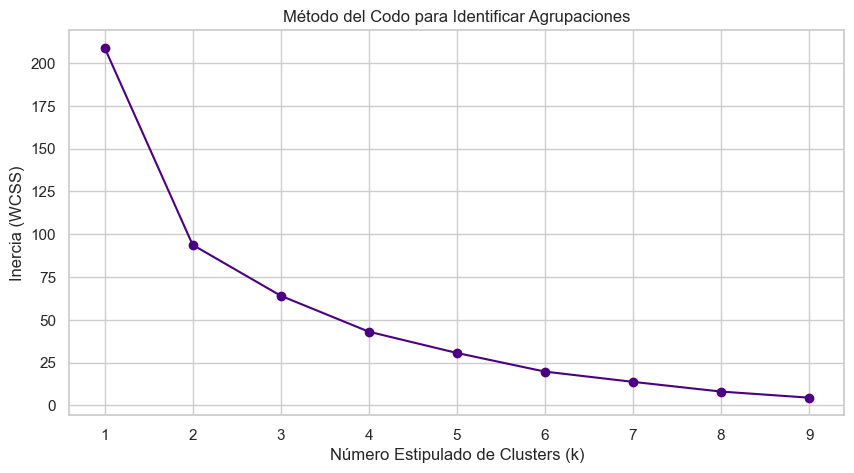

In [154]:
wcss = []
k_range = range(1, 10)

for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans_temp.fit(X_scaled)
    wcss.append(kmeans_temp.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, wcss, marker='o', linestyle='-', color='indigo')
plt.title('Método del Codo para Identificar Agrupaciones')
plt.xlabel('Número Estipulado de Clusters (k)')
plt.ylabel('Inercia (WCSS)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

## 4.2 Entrenamiento del Modelo y Visualización de las 24 Dimensiones

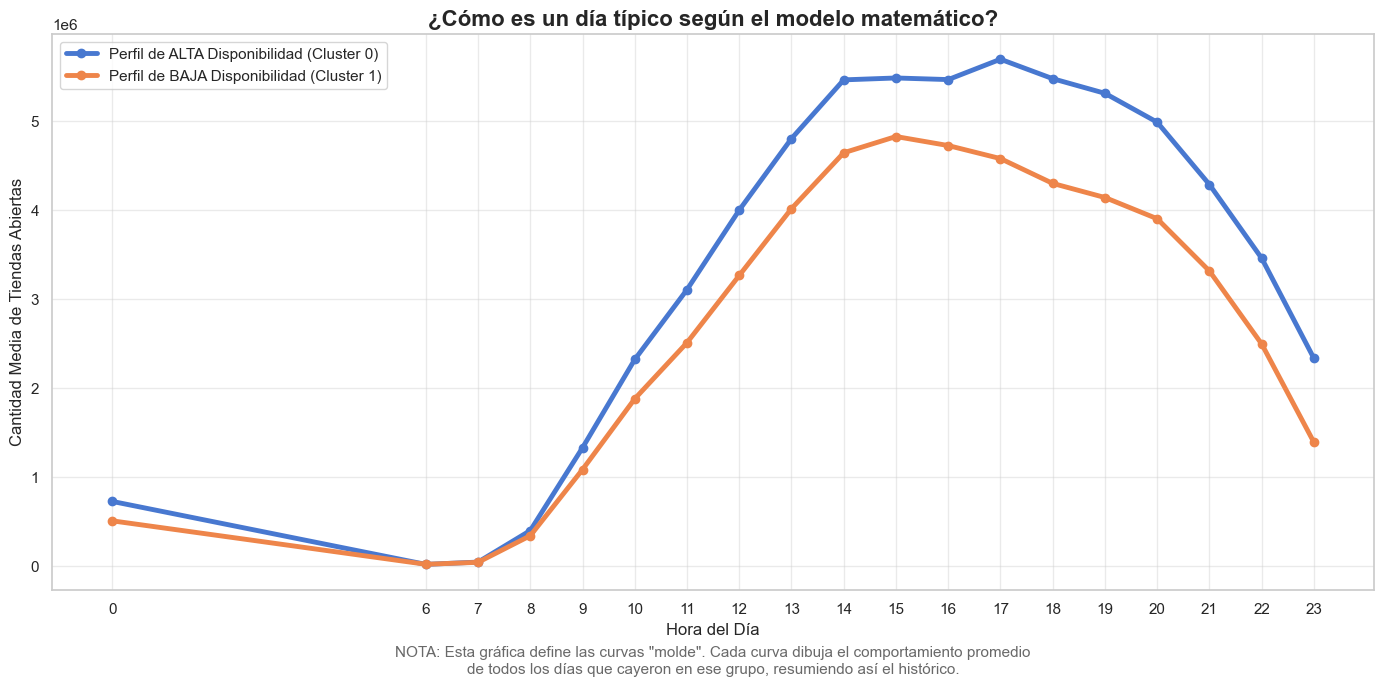

In [155]:
k_optimo = 2
kmeans = KMeans(n_clusters=k_optimo, init='k-means++', random_state=42, n_init=10)
clusters_pred = kmeans.fit_predict(X_scaled)
df_clustering['cluster'] = clusters_pred

centroides_scaled = kmeans.cluster_centers_
centroides_origin = scaler.inverse_transform(centroides_scaled)

plt.figure(figsize=(14, 7))
horas_cols = [c for c in df_clustering.columns if str(c) != 'cluster']
horas_num = [int(float(h)) for h in horas_cols]

for i in range(k_optimo):
    # Tratar de darle un nombre humano al clúster según su altura promedio
    promedio = centroides_origin[i].mean()
    etiqueta = 'Perfil de ALTA Disponibilidad' if promedio > centroides_origin.mean() else 'Perfil de BAJA Disponibilidad'
    plt.plot(horas_num, centroides_origin[i], marker='o', linewidth=3.5, label=f'{etiqueta} (Cluster {i})')

plt.title('¿Cómo es un día típico según el modelo matemático?', fontsize=16, fontweight='bold')
plt.xlabel('Hora del Día', fontsize=12)
plt.ylabel('Cantidad Media de Tiendas Abiertas', fontsize=12)
plt.xticks(horas_num)
plt.legend()
plt.grid(True, alpha=0.4)

plt.annotate('NOTA: Esta gráfica define las curvas "molde". Cada curva dibuja el comportamiento promedio\nde todos los días que cayeron en ese grupo, resumiendo así el histórico.',
            xy=(0.5, -0.15), xycoords='axes fraction', ha='center', fontsize=11, color='dimgray')
plt.tight_layout()
plt.show()


## 4.3 Visualización Espacial y Reducción de Dimensionalidad (PCA)
Para poder ver "clusters" en un plano XY normal, aplastaremos matemáticamente estas 24 horas a solo dos Componentes Principales.

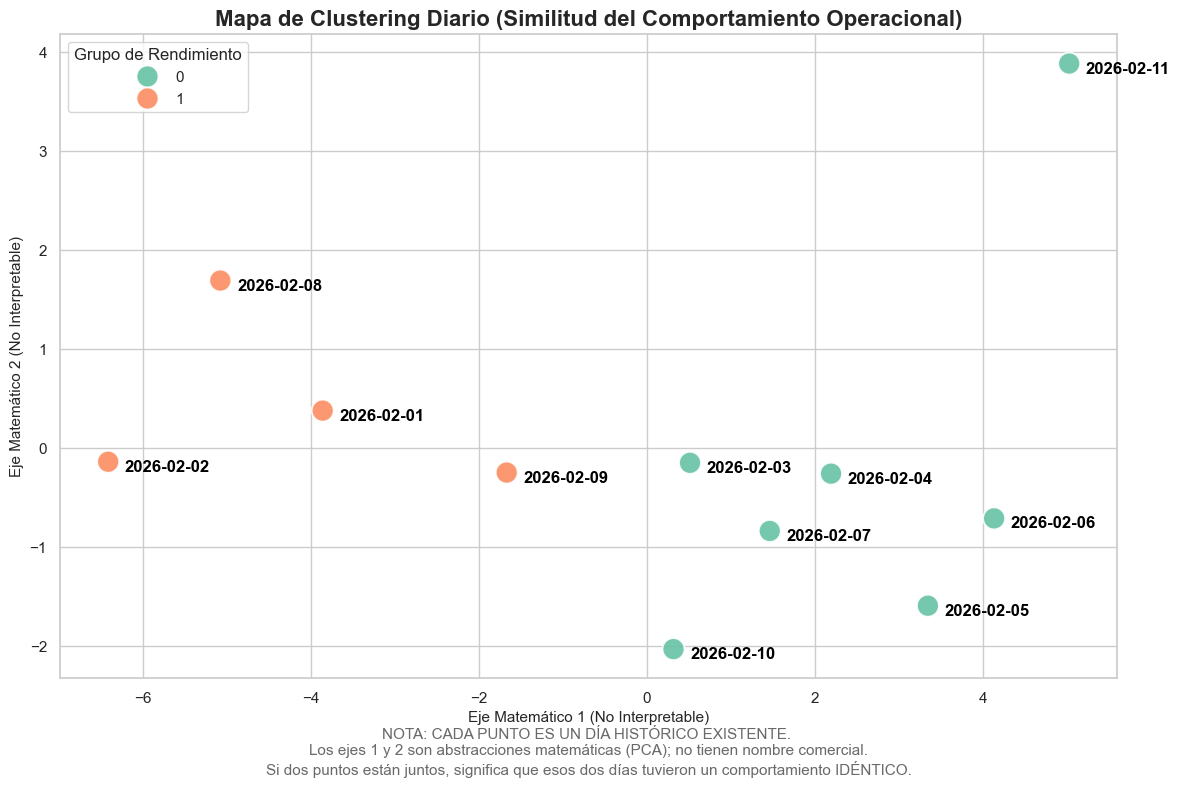

In [156]:
pca = PCA(n_components=2)
principals = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(data=principals, columns=['PC1', 'PC2'])
df_pca['cluster'] = df_clustering['cluster'].values
df_pca['date'] = df_clustering.index.values # Extraemos explícitamente las FECHAS para etiquetar puntos

plt.figure(figsize=(12, 8))
ax = sns.scatterplot(x='PC1', y='PC2', hue='cluster', data=df_pca, palette='Set2', s=250, alpha=0.9)

# Imprimir la FECHA sobre cada punto exacto para contexto de negocio
for i in range(df_pca.shape[0]):
    ax.text(df_pca['PC1'][i]+0.2, df_pca['PC2'][i]-0.1, df_pca['date'][i], 
            horizontalalignment='left', size='medium', color='black', weight='semibold')

plt.title('Mapa de Clustering Diario (Similitud del Comportamiento Operacional)', fontsize=16, fontweight='bold')
plt.xlabel('Eje Matemático 1 (No Interpretable)', fontsize=11)
plt.ylabel('Eje Matemático 2 (No Interpretable)', fontsize=11)
plt.legend(title='Grupo de Rendimiento')

plt.annotate('NOTA: CADA PUNTO ES UN DÍA HISTÓRICO EXISTENTE. \nLos ejes 1 y 2 son abstracciones matemáticas (PCA); no tienen nombre comercial.\nSi dos puntos están juntos, significa que esos dos días tuvieron un comportamiento IDÉNTICO.',
            xy=(0.5, -0.15), xycoords='axes fraction', ha='center', fontsize=11, color='dimgray')
plt.tight_layout()
plt.show()


## 4.4 Guardar Outputs Analíticos (K-Means)
Tal como lo requiere la arquitectura del proyecto, crearemos una ruta sagrada para el BLOQUE 2 y BLOQUE 3. Todos los hallazgos valiosos del Machine Learning se exportarán a la carpeta **`DATOS_FINAL_MODELOS`**. De ahí los leerá el Dashboard Web de nuestro cliente.

In [157]:
final_output_path = r'../../../DATOS/DATOS_FINAL_MODELOS/'
os.makedirs(final_output_path, exist_ok=True)

# Guardar Resultados PCA (Puntos 2D y sus fechas) para el Scatterplot del Web Dashboard
df_pca.to_csv(os.path.join(final_output_path, 'DASHBOARD_PCA_Clusters.csv'), index=False)

# Guardar Resultados de las curvas horarias Centroides
df_clustering.to_csv(os.path.join(final_output_path, 'DASHBOARD_KMEANS_Results.csv'))

print(f"¡Modelos de Clustering empaquetados y guardados en -> {final_output_path}")

¡Modelos de Clustering empaquetados y guardados en -> ../../../DATOS/DATOS_FINAL_MODELOS/


# 5. Modeling y Evaluación (Forecasting Supervisado)
A continuación implementaremos la segunda estrategia y la última fase de CRISP-DM. Tomaremos el dataset `AVAILABILITY-hourly.csv` para entrenar a un modelo capaz de predecir cuántas tiendas estarán disponibles temporalmente hacia el futuro.
Utilizaremos `Random Forest Regressor` inyectándole conocimiento como los Lags (Rezagos) de tiempo pasados, un truco súper eficaz de Data Science.

In [158]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Leemos de nuevo la serie
df_hourly = pd.read_csv('../../../DATOS/DATOS_PROCESADOS/AVAILABILITY-hourly.csv')
df_hourly['timestamp'] = pd.to_datetime(df_hourly['timestamp'])
df_hourly.sort_values('timestamp', inplace=True)
df_hourly.set_index('timestamp', inplace=True)

# FEATURE ENGINEERING PARA SERIES TEMPORALES
# Le pasamos al modelo el estado de hace 1 hora, 2 horas y 24 horas (estacionalidad diaria directa)
df_hourly['lag_1'] = df_hourly['visible_stores'].shift(1)
df_hourly['lag_2'] = df_hourly['visible_stores'].shift(2)
df_hourly['lag_24'] = df_hourly['visible_stores'].shift(24)

# Como el modelo no puede entrenar con celdas "vacías" de las primeras 24 hrs que no tienen "pasado", las podamos
df_model = df_hourly.dropna().copy()
print("Matriz temporal enriquecida con variables desfasadas.")

Matriz temporal enriquecida con variables desfasadas.


## 5.1 Entrenamiento y Predicción con Partición de Tiempo
Aislaremos las últimas 25 horas del dataset como zona incógnita (Test) simulando que queremos "predecir" lo que pasará al día siguiente. El modelo se entrenará solo con la primera parte de la historia.

In [159]:
test_size = 25 

train = df_model.iloc[:-test_size].copy()
test = df_model.iloc[-test_size:].copy()

X_train = train[['lag_1', 'lag_2', 'lag_24']]
y_train = train['visible_stores']

X_test = test[['lag_1', 'lag_2', 'lag_24']]
y_test = test['visible_stores']

# Ensamblamos los Árboles
rf_model = RandomForestRegressor(n_estimators=150, max_depth=6, min_samples_leaf=4, random_state=42)
rf_model.fit(X_train, y_train)

# Aplicamos la predicción al futuro oscuro
predicciones = rf_model.predict(X_test)
test['predictions'] = predicciones.round(0).astype(int)

print("✅ Modelo RF Autorregresivo Evaluado y Predicciones Creadas.")

✅ Modelo RF Autorregresivo Evaluado y Predicciones Creadas.


## 5.2 Evaluación Matemáticas Estándar de Regresión

In [160]:
from sklearn.metrics import mean_absolute_percentage_error

# Calcular predicciones y Métricas en Entorno de Train (Conocido)
pred_train = rf_model.predict(X_train)
mae_train = mean_absolute_error(y_train, pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))
mape_train = mean_absolute_percentage_error(y_train, pred_train)

# Calcular predicciones y Métricas en Entorno de Test (Inédito)
mae_test = mean_absolute_error(y_test, predicciones)
rmse_test = np.sqrt(mean_squared_error(y_test, predicciones))
r2_test = r2_score(y_test, predicciones)
mape_test = mean_absolute_percentage_error(y_test, predicciones)

print(f"========== RATING DEL MODELO (CONTROL DE OVERFITTING) ==========")
print(f"--- TRAIN METRICS ---")
print(f"MAE: {mae_train:.1f} tiendas")
print(f"RMSE: {rmse_train:.1f} tiendas")
print(f"MAPE (Error Porcentual): {mape_train:.2%}")
print(f"\n--- TEST METRICS ---")
print(f"MAE: {mae_test:.1f} tiendas")
print(f"RMSE: {rmse_test:.1f} tiendas")
print(f"MAPE (Error Porcentual): {mape_test:.2%} (Margen absoluto por cada 100 tiendas!)")
print(f"R2-Score: {r2_test:.2%}")

# Guardar métricas incluyendo MAPE para la Web
metricas_df = pd.DataFrame({
    'Metrica': ['MAE_TRAIN', 'RMSE_TRAIN', 'MAPE_TRAIN', 'MAE_TEST', 'RMSE_TEST', 'MAPE_TEST', 'R2_TEST'],
    'Valor': [mae_train, rmse_train, mape_train, mae_test, rmse_test, mape_test, r2_test]
})
os.makedirs(final_output_path, exist_ok=True)
metricas_df.to_csv(os.path.join(final_output_path, 'DASHBOARD_FORECAST_MetricsSummary.csv'), index=False)
print("\n✅ Evaluación MAPE incorporada. Métricas exportadas a la bóveda estratégica.")


========== RATING DEL MODELO (CONTROL DE OVERFITTING) ==========
--- TRAIN METRICS ---
MAE: 124622.7 tiendas
RMSE: 186042.2 tiendas
MAPE (Error Porcentual): 9.06%

--- TEST METRICS ---
MAE: 234325.5 tiendas
RMSE: 495819.2 tiendas
MAPE (Error Porcentual): 9.36% (Margen absoluto por cada 100 tiendas!)
R2-Score: 94.30%

✅ Evaluación MAPE incorporada. Métricas exportadas a la bóveda estratégica.


## 5.3 Contraste Visual de Regresión y Exportación
Guardamos los resultados del Forecast para que la web y el chatbot lo expongan en tablas o interroguen libremente sus aciertos.

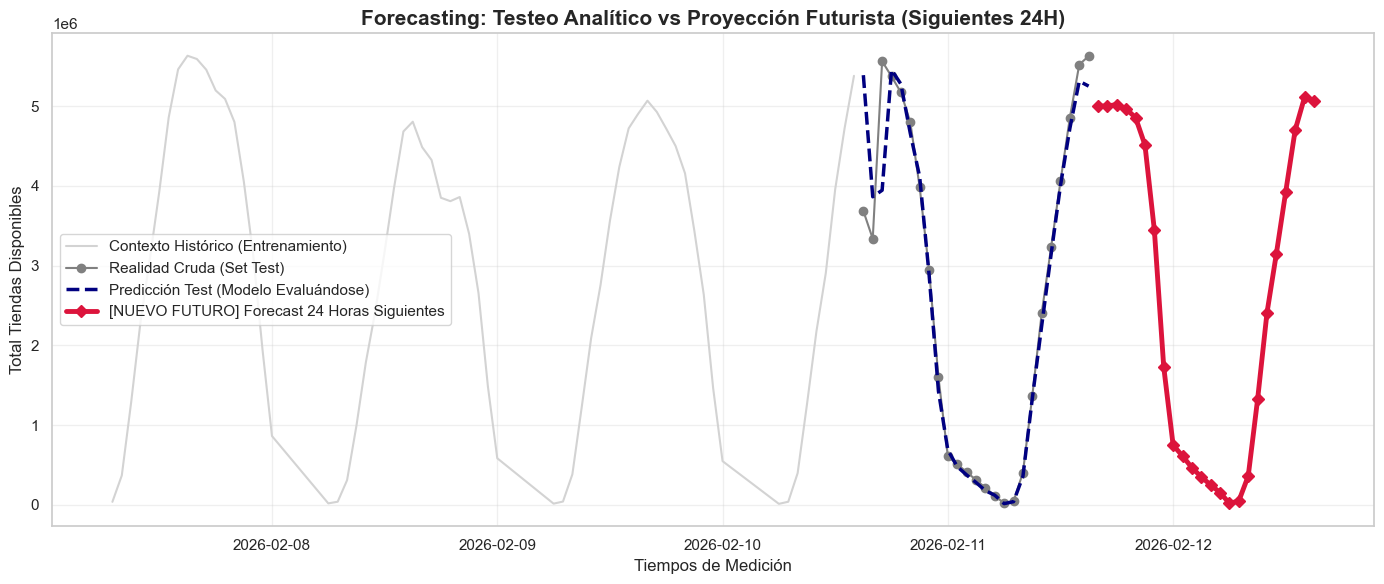

✅ Predicciones absolutas de futuro exportadas exitosamente a DATOS_FINAL_MODELOS


In [161]:
# Generar predicciones Puras hacia el FUTURO INVISIBLE (Próximas 24 horas)
last_timestamp = df_model.index[-1]
future_times = [last_timestamp + pd.Timedelta(hours=i) for i in range(1, 25)]
future_pred = []

# Recolectamos todo el registro estadístico en memoria para alimentar los Rezagos Lags
history_vals = list(df_model['visible_stores'].values)

import warnings; warnings.filterwarnings('ignore') # Evitamos la alerta inofensiva de Numpy al inferir sin DataFrame Head

for i in range(24):
    lag_1 = history_vals[-1]
    lag_2 = history_vals[-2]
    lag_24 = history_vals[-24]
    
    pred = rf_model.predict([[lag_1, lag_2, lag_24]])[0]
    pred = int(round(pred, 0))
    future_pred.append(pred)
    
    # AUTORREGRESIÓN: Agregamos nuestra propia predicción como si fuera un evento "pasado" para generar la hora siguiente.
    history_vals.append(pred)

df_future = pd.DataFrame({'visible_stores_futuro': future_pred}, index=future_times)

plt.figure(figsize=(14, 6))
# Ploteamos historia (Train)
plt.plot(train.index[-80:], train['visible_stores'][-80:], label='Contexto Histórico (Entrenamiento)', color='lightgrey')
# Ploteamos Set de Prueba Test (Para evaluar el Error MAE/RMSE y que no haya Overfitting)
plt.plot(test.index, test['visible_stores'], label='Realidad Cruda (Set Test)', color='gray', marker='o')
plt.plot(test.index, test['predictions'], label='Predicción Test (Modelo Evaluándose)', color='navy', linestyle='--', linewidth=2.5)

# Ploteamos la Proyección Final Pura 24h!
plt.plot(df_future.index, df_future['visible_stores_futuro'], label='[NUEVO FUTURO] Forecast 24 Horas Siguientes', color='crimson', linestyle='-', linewidth=3.5, marker='D')

plt.title('Forecasting: Testeo Analítico vs Proyección Futurista (Siguientes 24H)', fontsize=15, fontweight='bold')
plt.xlabel('Tiempos de Medición')
plt.ylabel('Total Tiendas Disponibles')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Grabamos el Modelo Testeado en CSV separados. El Dashboard de la fase 2 los usará abundantemente!
df_export_test = test.reset_index()[['timestamp', 'visible_stores', 'predictions']]
df_export_test.to_csv(os.path.join(final_output_path, 'DASHBOARD_FORECAST_TestMetrics.csv'), index=False)

df_export_future = df_future.reset_index()
df_export_future.rename(columns={'index': 'timestamp'}, inplace=True)
df_export_future.to_csv(os.path.join(final_output_path, 'DASHBOARD_FORECAST_Future24H.csv'), index=False)
print("✅ Predicciones absolutas de futuro exportadas exitosamente a DATOS_FINAL_MODELOS")


## 5.4 Feature Importance (Explicabilidad del Comportamiento Operacional)
Para cumplir con la meta analítica estructurada en la sección de Preparation, utilizaremos nuestro archivo `AVAILABILITY-features.csv`.
Entrenaremos un modelo global sobre TODOS nuestros factores ambientales (la hora, el día de la semana, fin de semana) para que el Machine Learning nos diga **MATEMÁTICAMENTE QUÉ VARIABLE PESA MÁS** a la hora de determinar si habrán muchas o pocas tiendas abiertas. Esto brinda muchísimo valor al cliente.

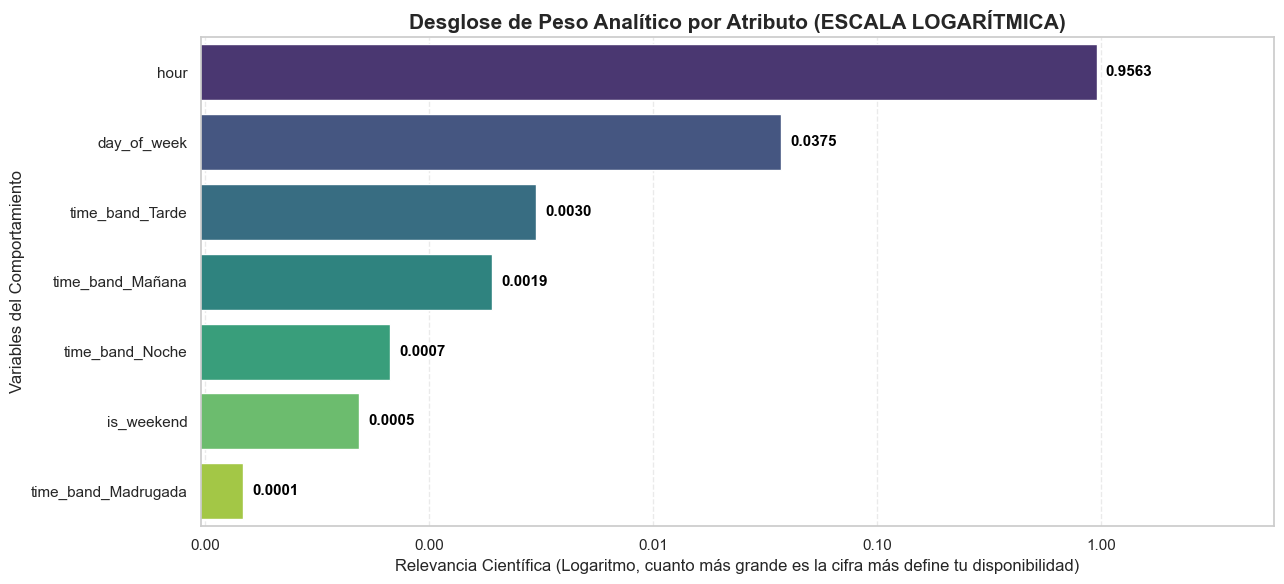

✅ Rank de Importancia exportado exitosamente a la bóveda estratégica.


In [162]:
# Lo pasamos a Serie de Pandas para fácil plotting
feat_importances = pd.Series(importances, index=feature_names)
feat_importances = feat_importances.sort_values(ascending=False)

plt.figure(figsize=(13, 6))
ax = sns.barplot(x=feat_importances.values, y=feat_importances.index, palette='viridis')

# Para solucionar el problema de compresión de escalas (donde la Hora comprime todo), usamos ESCALA LOGARÍTMICA
ax.set_xscale('log')
from matplotlib.ticker import ScalarFormatter
ax.xaxis.set_major_formatter(ScalarFormatter())

# Añadimos Textos Numericos para poder ver los datos concretos ya que la escala es log
for p in ax.patches:
    ax.annotate(f'{p.get_width():.4f}', (p.get_width() * 1.1, p.get_y() + p.get_height() / 2.),
                ha='left', va='center', size=11, color='black', weight='semibold')

plt.title('Desglose de Peso Analítico por Atributo (ESCALA LOGARÍTMICA)', fontsize=15, fontweight='bold')
plt.xlabel('Relevancia Científica (Logaritmo, cuanto más grande es la cifra más define tu disponibilidad)', fontsize=12)
plt.ylabel('Variables del Comportamiento', fontsize=12)
plt.xlim(right=ax.get_xlim()[1]*4) # Ampliar visualmente el límite X para que entre el texto
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Exportamos las variables más valiosas para consumo del LLM en la fase 3 o el Dashboard
final_output_path = r'../../../DATOS/DATOS_FINAL_MODELOS/'
os.makedirs(final_output_path, exist_ok=True)
feat_importances.to_frame('Importance').to_csv(os.path.join(final_output_path, 'DASHBOARD_FEATURE_IMPORTANCE.csv'))
print(f"✅ Rank de Importancia exportado exitosamente a la bóveda estratégica.")
